###**Into the SpiderVerse !**
Classify Spider People Using YOLOv8n<br><br>
Before you begin:
- Ensure that you have selected T4 GPU Runtime
- You have uploaded the aug_dataset_with_unknown.zip folder to Google Drive
<br>
Let's begin !!!

### Step 1: Mount Google Drive
We do this to access the dataset stored in our Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 2: Extract the Uploaded Dataset
The dataset is in the form of a ZIP file. We will extract it into a folder (Unzip) it to access the images inside

In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/ML_Datasets/aug_dataset_with_unknown.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

dataset_path = "/content/dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root, "->", len(files), "images")

/content/dataset -> 0 images
/content/dataset/__MACOSX -> 1 images
/content/dataset/__MACOSX/aug_dataset_with_unknown -> 10 images
/content/dataset/__MACOSX/aug_dataset_with_unknown/hobie_brown -> 394 images
/content/dataset/__MACOSX/aug_dataset_with_unknown/spider_ham -> 398 images
/content/dataset/__MACOSX/aug_dataset_with_unknown/miles_morales -> 395 images
/content/dataset/__MACOSX/aug_dataset_with_unknown/pavitr_prabhakar -> 394 images
/content/dataset/__MACOSX/aug_dataset_with_unknown/miguel_ohara -> 395 images
/content/dataset/__MACOSX/aug_dataset_with_unknown/spider_man_noir -> 396 images
/content/dataset/__MACOSX/aug_dataset_with_unknown/not_spider_person -> 396 images
/content/dataset/__MACOSX/aug_dataset_with_unknown/gwen_stacy -> 397 images
/content/dataset/__MACOSX/aug_dataset_with_unknown/peter_b_parker -> 393 images
/content/dataset/aug_dataset_with_unknown -> 1 images
/content/dataset/aug_dataset_with_unknown/hobie_brown -> 394 images
/content/dataset/aug_dataset_with_u

### Step 3: Split Dataset into Train and Test Subsets
This will allow us to train and check the accuracy of the model we trained

In [6]:
import random
import shutil

source_dir = "/content/dataset/aug_dataset_with_unknown"
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"
test_dir="/content/dataset/test"
split_ratio = 0.8

classes = os.listdir(source_dir)

for cls in classes:
    if cls == ".DS_Store":
        continue
    class_path = os.path.join(source_dir, cls)
    images = os.listdir(class_path)

    random.shuffle(images)

    split_index = int(len(images) * split_ratio)

    train_images = images[:split_index]
    remaining_images = images[split_index:]

    half_index=len(remaining_images)//2
    val_images=images[:half_index]
    test_images=images[half_index:]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir,cls),exist_ok=True)

    for img in train_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(train_dir, cls, img)
        )

    for img in val_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(val_dir, cls, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(class_path,img),
            os.path.join(test_dir,cls,img)
        )

print("Dataset split completed!")

Dataset split completed!


### Step 4: Check the Train and Test parts that we have split
Check how many images are there for each Spider-person

In [7]:
for root, dirs, files in os.walk("/content/dataset/train"):
    print(root, len(files))

/content/dataset/train 0
/content/dataset/train/hobie_brown 315
/content/dataset/train/spider_ham 318
/content/dataset/train/miles_morales 316
/content/dataset/train/pavitr_prabhakar 315
/content/dataset/train/miguel_ohara 316
/content/dataset/train/spider_man_noir 316
/content/dataset/train/not_spider_person 316
/content/dataset/train/gwen_stacy 317
/content/dataset/train/peter_b_parker 314


### Step 5: Install the ultralytics library
This is the library that contains the function to invoke our YOLOv8n model

In [8]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.2 MB/s eta 0:00:00


### Step 6: Invoke the model and train it on the training set


In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

model.train(
    data="/content/dataset",
    epochs=20,
    imgsz=224,
    batch=32
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bdb8521e750>
curves: []
curves_results: []
fitness: 1.0
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 1.0, 'metrics/accuracy_top5': 1.0, 'fitness': 1.0}
save_dir: PosixPath('/content/runs/classify/train')
speed: {'preprocess': 0.17703032112812778, 'inference': 1.0319601380282442, 'loss': 0.00039314085190941936, 'postprocess': 0.00031501126293630773}
top1: 1.0
top5: 1.0

And voila... The Training is finally done !!!

### Step 7: Save the updated parameters of the model
This will save us time the next time we call the same YOLOv8n model. We give it these parameters to fine-tune it

In [10]:
from google.colab import files

files.download('runs/classify/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Step 8: Test the model on a random image
Let's test if the model can actually classify

In [11]:
from ultralytics import YOLO

model = YOLO("runs/classify/train/weights/best.pt")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

0: 224x224 hobie_brown 1.00, miguel_ohara 0.00, gwen_stacy 0.00, spider_ham 0.00, peter_b_parker 0.00, 0.3ms
1: 224x224 hobie_brown 1.00, miles_morales 0.00, spider_man_noir 0.00, not_spider_person 0.00, gwen_stacy 0.00, 0.3ms
2: 224x224 hobie_brown 1.00, miles_morales 0.00, spider_man_noir 0.00, not_spider_person 0.00, gwen_stacy 0.00, 0.3ms
3: 224x224 hobie_brown 1.00, spider_man_noir 0.00, spider_ham 0.00, miles_morales 0.00, peter_b_parker 0.00, 0.3m

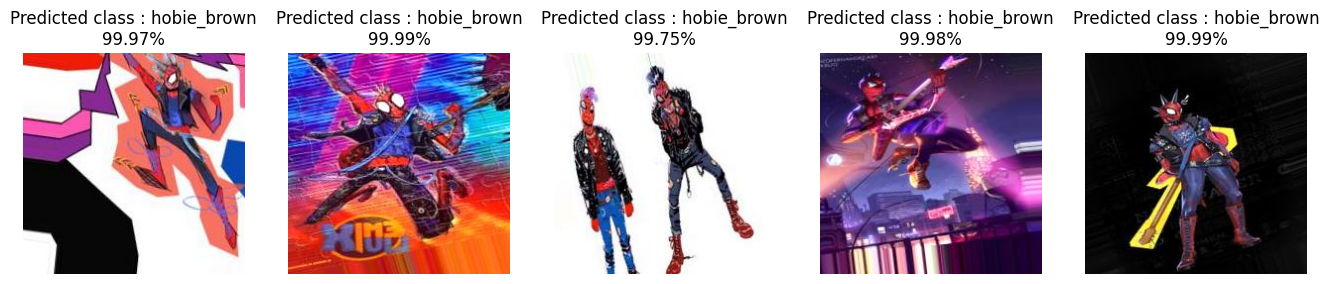

In [15]:

import os
from PIL import Image
import matplotlib.pyplot as plt

test_dir = "/content/dataset/test"

image_paths = []

# collect all images path from subfolders
for cls in os.listdir(test_dir):
    class_path = os.path.join(test_dir, cls)

    if not os.path.isdir(class_path):
        continue

    for img in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, img))

# confidence threshold
threshold = 0.92

# predict all images
results = model.predict(image_paths)

# create single row plot
plt.figure(figsize=(20,4))

for i, path in enumerate(image_paths[:5]):

    img = Image.open(path)

    pred_class = results[i].names[results[i].probs.top1]
    confidence = results[i].probs.top1conf.item()

    # Apply threshold
    if confidence < threshold:
        pred_class = "Unknown"

    plt.subplot(1, 6, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted class : {pred_class}\n{confidence*100:.2f}%")

plt.show()

### Accuracy on the test dataset


In [16]:
correct = 0
total = len(image_paths)

for i, path in enumerate(image_paths):

    true_class = path.split("/")[-2]

    pred_class = results[i].names[results[i].probs.top1]

    if pred_class == true_class:
        correct += 1

accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.78%


By Using default Function For Finding Accuracy

In [17]:
model.val(split="test")

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/dataset/train... found 2843 images in 9 classes ✅ 
val: /content/dataset/val... found 355 images in 9 classes ✅ 
test: /content/dataset/test... found 3203 images in 9 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 328.7±147.3 MB/s, size: 8.3 KB)
test: Scanning /content/dataset/test... 3203 images, 0 corrupt: 100% ━━━━━━━━━━━━ 3203/3203 3.4Kit/s 0.9s
test: New cache created: /content/dataset/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 201/201 21.5it/s 9.4s
                   all      0.998          1
Speed: 0.1ms preprocess, 1.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bdb84566480>
curves: []
curves_results: []
fitness: 0.9989072680473328
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9978145360946655, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9989072680473328}
save_dir: PosixPath('/content/runs/classify/val')
speed: {'preprocess': 0.1057904111781929, 'inference': 1.2273055067128118, 'loss': 0.004046107089727358, 'postprocess': 0.001222069623939768}
top1: 0.9978145360946655
top5: 1.0